### Tratamento dos dados

Os dados brutos contém informações sobre cada disciplina cursada por cada aluno que está ou já esteve matriculado no curso de Ciências da Computação da UFES. O tratamento teve como principal objetivo extrair as informações relevantes por aluno, a fim de reduzir a base de dados para apenas informações úteis. Assim, foram consideradas informações que dizem respeito à forma de ingresso e desempenho do aluno, bem como informações de quais disciplinas fez, média final em cada disciplina e quantas vezes foi feita. 

Inicialmente, os dados no formato .csv foram carregados, a função `clean_names()` do pacote `janitor`foi utilizada para padronizar os nomes das variáveis, removendo espaços e caracteres especiais para facilitar o trabalho. Em seguida, os alunos com identificação ausente foram descartados e a combinação das colunas `nome_cripto`e `matr_cripto` foi convertida em uma identificação única para cada aluno, representada pela coluna `id_aluno`. Além disso, a função `select()` do pacote `dplyr` foi utilizada para remover variáveis que não contribuiriam para as análises.



In [6]:
# Carregando pacotes
library(readr)
library(janitor)
library(dplyr)
library(tidyr)
library(stringr)

# Lendo e tratando os dados
dados_aux <- read_delim("C:/Users/maria/OneDrive - Universidade Federal do Espírito Santo/Documentos/Analise_evasao_CT/data/CienciaDaComputacaoCT_com_cripto.csv", 
                    delim = ";", escape_double = FALSE, trim_ws = TRUE,
                     locale = locale(encoding = "Latin1")) |>
  clean_names() |>
  filter(!is.na(id_curso_aluno)) |>
  group_by(nome_cripto, matr_cripto) |>
  mutate(id_aluno = cur_group_id()) |>
  ungroup() |>
  select(-c(id_curso_aluno, cod_curso, nome_unidade, nome_docente,
            matr_cripto, nome_cripto, cod_disciplina, titulacao_docente, 
            sigla_situacao, situacao_item, sigla_semestre, cod_forma_evasao,
            crn))

Rows: 27822 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: ";"
chr (19): 'NOME_UNIDADE', 'DESCR_ESTRUTURA', 'TIPO_DISCIPLINA', 'COD_DISCIPL...
dbl (16): 'ID_CURSO_ALUNO', 'COD_CURSO', 'NUM_VERSAO', 'CH_TOTAL_VERSAO_CURS...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Para fins de organização no tratamento de dados, primeiro foram consideradas as informações do aluno, como forma de evasão, ano de evasão, coeficiente de rendimento acumulado, semestre de evasão e ano de ingresso. Por essa situação se enquadrar na área de análise de sobrevivência, foi criada a variável binária `status` para indicar a presença de censura. Aqueles alunos que ainda estão matriculados no curso são considerados observações censuradas à direita, pois tem-se apenas o limite inferior sobre o tempo até sair do curso, todos os outros tempos até evasão são considerados. Se o aluno já saiu do curso, seja por formatura ou não, a variável `status` recebe o valor 1, caso contrário o valor 0. Também é calculado o tempo até evasão representado pela variável `anos_ate_evasao`. O cálculo é feito considerando a diferença entre o ano de ingresso e ano de evasão para aqueles que já saíram do curso. Para os matriculados, o tempo até evasão censurado será a diferença entre o ano atual (2025) e o ano de ingresso.

In [7]:
dados_alunos <- dados_aux |>
  select(id_aluno, forma_evasao, ano_evasao, cra, semestre_evasao, ano_ingresso,
         forma_ingresso, cotista) |>
  distinct() |>
  mutate(status = ifelse(forma_evasao == "'Sem evasão'", 0, 1),
  anos_ate_evasao = case_when(forma_evasao != "'Sem evasão'" ~ ano_evasao - ano_ingresso,
                              forma_evasao == "'Sem evasão'" ~ 2025 - ano_ingresso)
  )

Para as informações a respeito das disciplinas dos alunos, foram extraídas apenas as informações: se fez ou não a disciplina, média final do aluno na disciplina e quantas vezes a disciplina foi feita pelo aluno. Primeiro, usando a função `expand_grid`, foram feitas todas as combinações entre alunos e disciplinas e observada a média final do aluno na mesma. Se a média final era um valor ausente, conclui-se que a disciplina não foi cursada pelo aluno. À variável binária que indica se a disciplina foi cursada ou não, atribui-se o nome `fez_{nome da disciplina}`. O número de vezes que a disciplina aparecia junto à identificação do aluno foi usado para concluir quantas vezes a disciplina foi feita pelo aluno, representada pela variável `numero_tentativas_{nome da disciplina}`. Para cada vez que o aluno fez a disciplina, também foi armazenada a média final do aluno, em variáveis na forma `media_final_{nome da disciplina}_{numero da tentativa}`. Além disso, os nomes das disciplinas foram padronizados e disciplinas com o nome 'Atividades Complementares' não foram consideradas.

In [8]:
########### Organizando informações das disciplinas feitas

todos <- expand_grid(
  id_aluno = unique(dados_aux$id_aluno),
  nome_disciplina = unique(dados_aux$nome_disciplina)
)

dados_completos <- todos |>
  full_join(dados_aux |> select(id_aluno, nome_disciplina, media_final, descricao_situacao,
                                descricao_semestre, ano,
                                num_versao,
                                descr_estrutura, ch_total, tipo_disciplina), 
            by = c("id_aluno", "nome_disciplina")) |>
  mutate(feita = ifelse(!is.na(media_final), "sim", "não"))

contagem_disciplinas <-  dados_aux |>
  count(id_aluno, nome_disciplina, name = "n_vezes")

dados_completos <- dados_completos |> left_join(contagem_disciplinas) |>
  mutate(
    n_vezes = ifelse(descr_estrutura %in% c("'03-Atividades Complementares'", "'04-Atividades Complementares'"),
                     NA, n_vezes)
  )

# Padroniza nomes de disciplina
dados_completos <- dados_completos |>
  mutate(
    nome_disciplina = iconv(nome_disciplina, from = "UTF-8", to = "ASCII//TRANSLIT"), # remove acentos
    nome_disciplina = str_replace_all(nome_disciplina, "[\\r\\n\\t]", ""),             # remove \r, \n, \t
    nome_disciplina = str_squish(nome_disciplina),                                     # tira espaços duplicados
    nome_disciplina = str_to_lower(nome_disciplina),                                   # tudo minúsculo
    nome_disciplina = str_replace_all(nome_disciplina, "[^a-z0-9]+", "_"),             # substitui símbolos por _
    nome_disciplina = str_replace_all(nome_disciplina, "_$", "")                       # remove "_" no final
  )


# Calcula a média obtida em cada disciplina (jncluindo feitas mais de uma vez)
dados_medias <- dados_completos |>
  filter(descricao_semestre %in% c("'1º Semestre'", "'2º Semestre'"), feita == "sim") |>
  group_by(id_aluno, nome_disciplina) |>
  mutate(tentativa = row_number()) |>
  ungroup() |>
  mutate(nome_coluna = paste0("media_final", nome_disciplina, "_", tentativa)) |>
  select(id_aluno, nome_coluna, media_final) |>
  pivot_wider(names_from = nome_coluna, values_from = media_final)

# Cria indicador binário para todas as disciplinas
dados_indicadores <- dados_completos |>
  filter(descricao_semestre %in% c("'1º Semestre'", "'2º Semestre'"), feita == "sim") |>
  distinct(id_aluno, nome_disciplina, feita) |>
  mutate(nome_coluna = paste0("fez", nome_disciplina)) |>
  select(id_aluno, nome_coluna, feita) |>
  pivot_wider(names_from = nome_coluna, values_from = feita, values_fill = "não")

# Indica quantas vezes cada aluno fez cada disciplina
dados_tentativas <- dados_completos |>
  filter(descricao_semestre %in% c("'1º Semestre'", "'2º Semestre'"), feita == "sim") |>
  group_by(id_aluno, nome_disciplina) |>
  summarise(numero_tentativas = n(), .groups = "drop") |>
  mutate(nome_coluna = paste0("numero_tentativas", nome_disciplina)) |>
  select(id_aluno, nome_coluna, numero_tentativas) |>
  pivot_wider(names_from = nome_coluna, values_from = numero_tentativas, values_fill = 0)

Joining with `by = join_by(id_aluno, nome_disciplina)`


Ao final, as informações a respeito dos alunos e das disciplinas cursadas por eles foram unidas em uma única base de dados utilizando a função `left_join()`. O conjunto de dados tratado está organizado da seguinte forma: cada linha representa um aluno e cada aluno aparece uma única vez, as colunas são as informações do aluno.

In [9]:
# UNINDO TUDO
dados_final <- dados_alunos |>
  left_join(dados_indicadores, by = "id_aluno") |>
  left_join(dados_medias, by = "id_aluno") |>
  left_join(dados_tentativas, by = "id_aluno") |>
  mutate(
    forma_ingresso = ifelse(id_aluno %in% c(594, 679, 848, 898),
                            "'Sisu/Reopção de curso'", forma_ingresso)
  ) |>
  distinct()

  head(dados_final)

id_aluno,forma_evasao,ano_evasao,cra,semestre_evasao,ano_ingresso,forma_ingresso,cotista,status,anos_ate_evasao,⋯,numero_tentativas_topicos_especiais_em_sistemas_mecanicos,numero_tentativas_calculo_aplicado_i,numero_tentativas_calculo_aplicado_ii,numero_tentativas_circuitos_eletricos,numero_tentativas_desenho_tecnico_mecanico,numero_tentativas_fisica_b1,numero_tentativas_mecanica_geral,numero_tentativas_top_esp_em_proces_de_dados,numero_tentativas_recuperacao_e_manejo_de_areas_degradadas,numero_tentativas_sistemas_operacionais_ii
<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
415,'Formado',2024,"8,01",'1º Semestre',2019,'Sisu','N',1,5,⋯,0,0,0,0,0,0,0,0,0,0
447,'Desligamento por Abandono',2012,"1,94",'2º Semestre',2011,'Vestibular','N',1,1,⋯,0,0,0,0,0,0,0,0,0,0
356,'Desistência',2024,"1,23",'1º Semestre',2021,'Sisu','S',1,3,⋯,0,0,0,0,0,0,0,0,0,0
42,'Sem evasão',NA,"3,88",NA,2024,'Sisu','N',0,1,⋯,0,0,0,0,0,0,0,0,0,0
360,'Formado',2023,"7,36",'1º Semestre',2017,'Sisu','N',1,6,⋯,0,0,0,0,0,0,0,0,0,0
144,'Desligamento: 3 reprovações em 1 disciplina',2012,"3,34",'1º Semestre',2008,'Vestibular','N',1,4,⋯,0,0,0,0,0,0,0,0,0,0


Foi necessário imputação de valores ausentes, por meio da criação da função `imputar_dados`. Em primeira instância, as variáveis com mais de 50% das observações com valores ausentes foram eliminadas, por não serem muito informativas. As variáveis referentes ao número de vezes que o aluno fez a disciplina com valores ausentes foi imputada com o valor 0, pois foi entendido que não foi cursada pelo aluno. Quanto à média final em cada disciplina, os valores ausentes foram imputados utilizando a mediana; o mesmo foi feito para todas as variáveis quantitativas. Já para as variáveis qualitativas, a média foi imputada.

In [ ]:
# Tratamento de valores ausentes
imputar_dados <- function(dados) {
  #Remover variáveis com >50% NAs
  limiar_remocao <- 0.5
  vars_para_remover <- sapply(dados, function(x) {
    sum(is.na(x)) / length(x) > limiar_remocao
  }) %>% which() %>% names()
  
  
  # Passo 2: Imputação conforme regras específicas
  dados_imputados <- dados |>
    mutate(across(
      .cols = everything(),
      .fns = ~ {
        nome_var <- cur_column()
        
        if (is.numeric(.x)) {
          # Variáveis que começam com "numero_tentativas": quando NA, o aluno não fez a matéria
          if (startsWith(nome_var, "numero_tentativas")) {
            ifelse(is.na(.x), 0, .x)
          } 
          # Variáveis que começam com "media": imputar mediana
          else if (startsWith(nome_var, "media")) {
            ifelse(is.na(.x), median(.x, na.rm = TRUE), .x)
          }
          # Demais variáveis numéricas: imputar mediana
          else {
            ifelse(is.na(.x), median(.x, na.rm = TRUE), .x)
          }
        } 
        else {
          # Variáveis que começam com "fez": imputar moda
          if (startsWith(nome_var, "fez")) {
            moda <- names(sort(table(.x), decreasing = TRUE))[1]
            ifelse(is.na(.x), moda, .x)
          }
          # Demais variáveis categóricas: imputar moda
          else {
            moda <- names(sort(table(.x), decreasing = TRUE))[1]
            ifelse(is.na(.x), moda, .x)
          }
        }
      }
    ))
  
  return(dados_imputados)
}

dados <- imputar_dados(dados_final)

Warning message in imputar_dados(dados_final):
"Variáveis removidas (mais de 50% NAs): media_final_topicos_especiais_em_programacao_i_1, media_final_calculo_ii_1, media_final_arquitetura_de_computadores_i_1, media_final_estrutura_de_dados_i_1, media_final_topicos_especiais_em_informatica_i_1, media_final_calculo_iii_b_1, media_final_estatistica_basica_1, media_final_engenharia_de_software_1, media_final_estrutura_de_dados_ii_1, media_final_linguagens_formais_e_automatos_1, media_final_programacao_iii_1, media_final_algoritmos_numericos_i_1, media_final_sistemas_operacionais_1, media_final_teoria_dos_grafos_1, media_final_topicos_especiais_em_informatica_ii_1, media_final_logica_para_computacao_ii_1, media_final_linguagens_de_programacao_1, media_final_redes_de_computadores_1, media_final_compiladores_1, media_final_interface_humano_computador_1, media_final_engenharia_de_software_i_1, media_final_banco_de_dados_i_1, media_final_computacao_e_sociedade_1, media_final_engenharia_de_softwa

## Análise Exploratória

## Análise das Curvas de Kaplan-Meier

A análise de sobrevivência é uma área da estatística voltada para o estudo do tempo até a ocorrência de um evento de interesse. No caso em análise, esse evento corresponde à evasão estudantil - o momento em que um aluno deixa o curso, seja devido a formatura ou antes da conclusão. Uma das ferramentas mais utilizadas nesse tipo de análise são as curvas de Kaplan-Meier, que estimam a função de sobrevivência de forma não paramétrica, levando em conta a censura nos dados, como nos casos em que o aluno ainda está matriculado ao final do período de observação. Essas curvas representam, ao longo do tempo, a proporção acumulada de alunos que permaneceram no curso, permitindo comparações entre diferentes grupos. No âmbito de interpretação, a cada ponto da curva, a altura indica a probabilidade de um aluno ainda estar vinculado ao curso até aquele período. Quedas mais acentuadas na curva representam momentos de maior evasão, enquanto curvas mais altas e estáveis indicam maior retenção. Por isso, as curvas de Kaplan-Meier são essenciais para entender padrões de permanência e abandono. 

A seguir são apresentadas três curvas de Kaplan-Meier: a primeira levando em consideração todos os alunos, independente da forma de evasão; a segunda composta apenas por alunos que tiveram evasão por formatura ou que ainda estão no curso; e a terceira constituída por aqueles que abandonaram antes de concluir o curso ou ainda estão cursando.

As curvas de Kaplan-Meier por estrato de variáveis não foram incluídas nesse relatório para não torná-lo tão extenso, mas podem ser visualizadas no link: [https://marianacfreitas.shinyapps.io/km_evasao/](https://marianacfreitas.shinyapps.io/km_evasao/). Foram consideradas apenas as variáveis referntes ao início do curso e ingresso do aluno, por no geral serem as mais importantes para determinar evasão.


Warning message:
"pacote 'ggsurvfit' foi compilado no R versão 4.4.3"
Loading required package: ggplot2

Carregando pacotes exigidos: ggpubr


Anexando pacote: 'survminer'


O seguinte objeto é mascarado por 'package:survival':

    myeloma




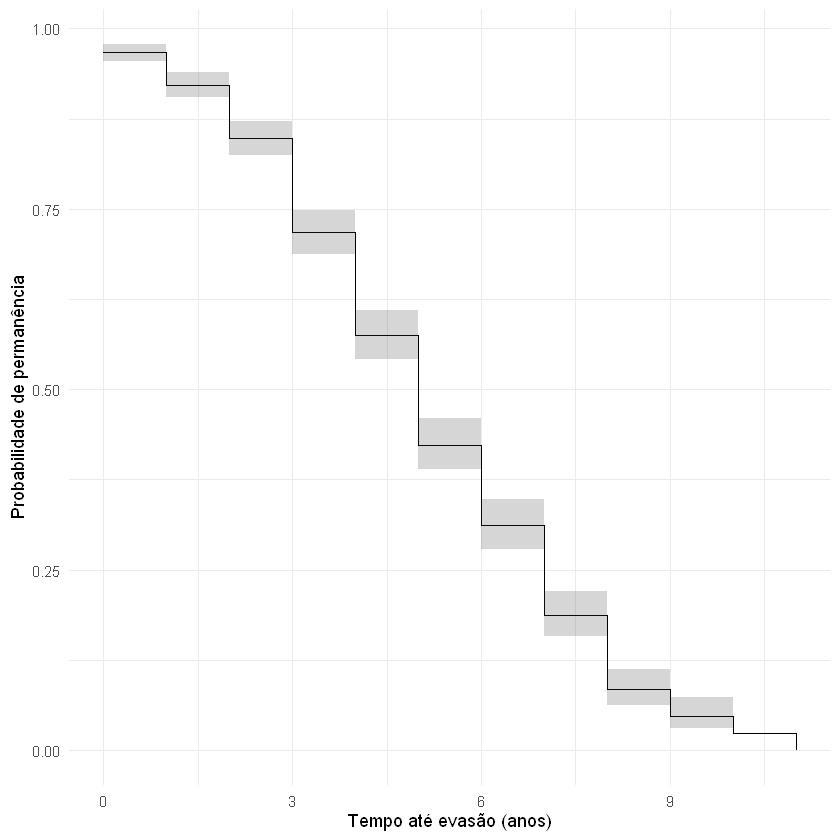

In [33]:
library(survival)
library(ggsurvfit)
library(readr)
library(dplyr)
library(survminer)
library(ggplot2)
library(ggsci)
library(survivalsvm)

# Apenas aqueles que formaram ou não concluíram o curso
dados_formados <- dados |>
  filter(forma_evasao == "'Formado'" | forma_evasao == "'Sem evasão'")

dados_quit <- dados |>
  filter(forma_evasao != "'Formado'")

################# CURVAS DE KAPLAN-MEIER GERAIS

# Criar objeto de sobrevivência
fit <- survfit(Surv(anos_ate_evasao, status) ~ 1, data = dados)

# Plotar curva de Kaplan-Meier
ggsurvplot_geral <- ggsurvfit(fit) +
  labs(
    x = "Tempo até evasão (anos)",
    y = "Probabilidade de permanência"  ) +
  add_confidence_interval() +
  theme_minimal()

print(ggsurvplot_geral)

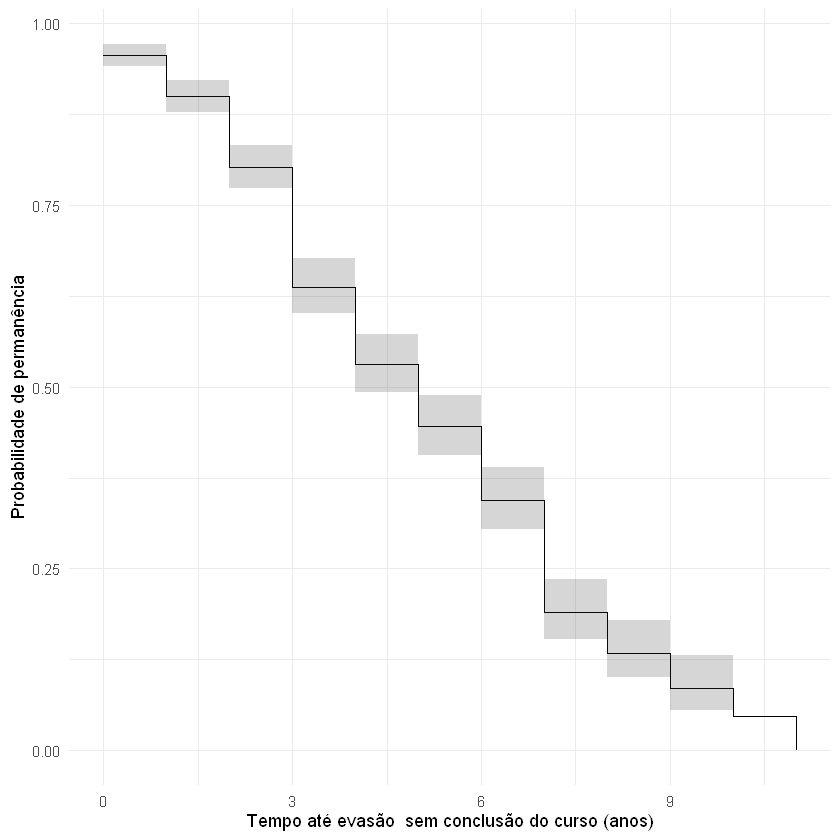

In [34]:
# Criar objeto de sobrevivência
fit_quit <- survfit(Surv(anos_ate_evasao, status) ~ 1, data = dados_quit)

# Plotar curva de Kaplan-Meier
ggsurvplot_quit <- ggsurvfit(fit_quit) +
  labs(
    x = "Tempo até evasão  sem conclusão do curso (anos)",
    y = "Probabilidade de permanência"  ) +
  add_confidence_interval() +
  theme_minimal()

print(ggsurvplot_quit)

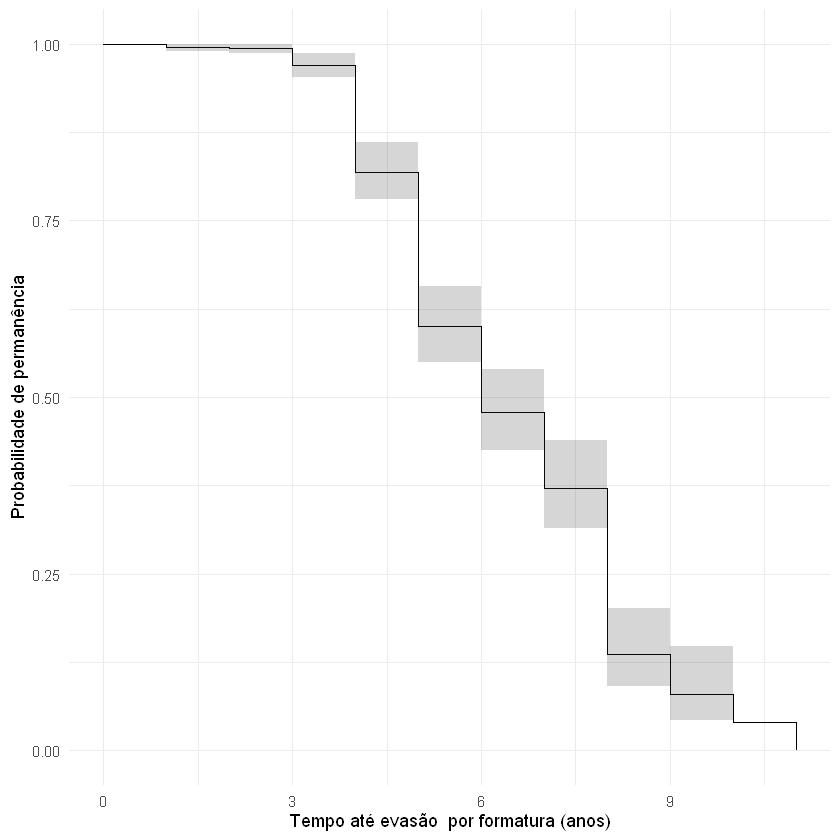

In [35]:
# Criar objeto de sobrevivência
fit_formados <- survfit(Surv(anos_ate_evasao, status) ~ 1, data = dados_formados)

# Plotar curva de Kaplan-Meier
ggsurvplot_formados <- ggsurvfit(fit_formados) +
  labs(
    x = "Tempo até evasão  por formatura (anos)",
    y = "Probabilidade de permanência"  ) +
  add_confidence_interval() +
  theme_minimal()

print(ggsurvplot_formados)

### Modelagem com Aprendizado de Máquina

No contexto de evasão de alunos, torna-se relevante propor modelos que sejam capazes de predizer quais alunos tem maior chance de sair do curso antes de formar. Dessa forma, a informação contribuiria na compreensão do colegiado sobre quais alunos tem risco de evadir e intervir a fim de promover a permanência no curso. Assim, aqui são apresentadas duas perspectivas diferentes de predição: a primeira forma faz uso da teoria de análise de sobrevivência juntamente com aprendizado de máquina para prever o tempo até evasão de cada aluno; já a segunda abordagem trata como um problema de classificação em que o objetivo é prever se o aluno irá evadir por formatura ou sem a conclusão do curso.

#### Modelagem em Análise de Sobrevivência

*Support Vector Machine* (SVM) é um algoritmo de aprendizado de máquina amplamente utilizado para tarefas de classificação e regressão. Sua principal ideia é encontrar um hiperplano ótimo que separe os dados em diferentes classes ou que se ajuste ao padrão de uma variável resposta, maximizando a margem entre as observações e esse hiperplano. Para lidar com dados que não são linearmente separáveis no espaço original, o SVM utiliza o chamado *kernel trick*, que transforma os dados para um espaço de maior dimensão onde essa separação se torna possível. Essa flexibilidade permite aplicar o SVM em diversos problemas com diferentes formas de relacionamentos entre variáveis.

Na área de análise de sobrevivência, o SVM pode ser adaptado para lidar com dados censurados, ou seja, situações em que o evento de interesse (evasão de um estudante) ainda não ocorreu até o final do acompanhamento. Uma das versões dessa adaptação é o *Survival SVM*, que busca encontrar uma função de predição que minimize o erro entre o tempo observado e o valor predito, penalizando predições inválidas em relação ao tempo censurado. Isso é feito, por exemplo, com o uso de uma margem de tolerância que define um intervalo aceitável de erro, considerando a censura à direita ao penalizar predições que estejam abaixo do tempo censurado.

Para avaliar o desempenho preditivo de modelos em análise de sobrevivência, uma métrica amplamente utilizada é o C-índex. Ele avalia o grau de concordância entre os tempos preditos e os tempos observados de eventos, levando em conta a censura. Um C-índex igual a 1 indica predições perfeitas. 

Aqui foi utilizado o *Survival SVM* com *kernel aditivo*, já que outros *kernels* testados, como o gaussiano e linear, obtiveram um baixo C-índex, indicando que não são ideais para descrever as relações entre as vaiáveis e o tempo de permanência nesse caso. Para o modelo, foram consideradas apenas variáveis a respeito da forma de evasão, informações sobre os alunos e aquelas referentes a matérias iniciais, pois o uso de todas as variáveis não era viável para treinamento do modelo. Para possibilitar o treinamento do modelo, também foi feito o tratamento de valores ausentes, removendo variáveis com maioria dos valores ausentes e imputando valores em outras.

O primeiro passo para a modelagem foi separar os dados em um conjunto de treino e de teste, que representaram 80% e 20% dos dados, respectivamente. Para reduzir o tempo de treinamento do modelo, foram utilizadas apenas as variáveis a respeito do ingresso do aluno, o coeficiente de rendimento acumulado e as informações a respeito das disciplinas dos três primeiros perídoos de curso, visto que são as que tiveram menos imputação de valores e que, no geral, mais influenciam na evasão ou não antes da formatura.


In [14]:
library(survivalsvm)

# Semente para reprodutibilidade
set.seed(2402)  

# Criar índice para divisão
indices <- sample(1:nrow(dados), size = floor(0.8 * nrow(dados)), replace = FALSE)

# Na variável cra, trocar "," por ".", para não ser confundido com character
dados$cra <- as.numeric(gsub(",", ".", dados$cra))


# Aplicando a função
dados1 <- dados |>
  select(
    forma_evasao,
    cra,
    forma_ingresso,
    cotista,
    status,
    anos_ate_evasao,
    fez_calculo_i,
    fez_calculo_ii,
    fez_programacao_i,
    fez_introducao_a_ciencia_da_computacao,
    fez_aspectos_teoricos_da_computacao,
    fez_elementos_de_logica_digital,
    fez_programacao_ii,
    numero_tentativas_calculo_i,
    numero_tentativas_calculo_ii,
    numero_tentativas_programacao_i,
    numero_tentativas_introducao_a_ciencia_da_computacao,
    numero_tentativas_aspectos_teoricos_da_computacao,
    numero_tentativas_elementos_de_logica_digital,
    numero_tentativas_programacao_ii,
    media_final_calculo_i_1,
    media_final_programacao_i_1,
    media_final_elementos_de_logica_digital_1,
    media_final_programacao_ii_1
  )

# Dividir os dados
treino <- dados1[indices, ]
teste <- dados1[-indices, ]

formula_dados <- as.formula(
  paste0("Surv(anos_ate_evasao, status) ~ ",
         paste(setdiff(names(treino), c("anos_ate_evasao", "status")), collapse = " + "))
)

svm_add <- survivalsvm(formula_dados,
                       data = treino,
                       type = "regression",
                       gamma.mu = 1,
                       kernel = "add_kernel")

pred_svm_add <- predict(svm_add, newdata = teste)$predicted

cindex_svm_add <- concordance(Surv(teste$anos_ate_evasao, teste$status) ~
                                as.vector(pred_svm_add))$concordance

cat("C-índice do modelo SVM com kernel aditivo:", cindex_svm_add, "\n")

Carregando pacotes exigidos: survival

Warning message:
"pacote 'survival' foi compilado no R versão 4.4.3"


C-índice do modelo SVM com kernel aditivo: 0.7314387 


Ao final, o C-índex obtido para o modelo foi de aproximadamente 0.73, indicando bom poder preditivo dos tempos de permanência dos alunos no curso.

#### Modelagem da classificação da Evasão dos Alunos

O primeiro passo para o treinamento foi reclassificar os estudantes conforme a forma de evasão. Como originalmente a variável `forma_evasao` apresenta várias classes, há poucas observações de cada classe e o modelo acaba tendo poder preditivo ruim devido ao treinamento com poucos dados. Dessa forma, os alunos foram dividios apenas entre aqueles que tiveram evasão por formatura ou não, enquanto os alunos ainda matriculados não foram considerados para treinar o modelo.

In [28]:
# Criar índice para divisão

# Aplicando a função
dados2 <- dados |>
  select(
    forma_evasao,
    cra,
    forma_ingresso,
    cotista,
    status,
    anos_ate_evasao,
    fez_calculo_i,
    fez_calculo_ii,
    fez_programacao_i,
    fez_introducao_a_ciencia_da_computacao,
    fez_aspectos_teoricos_da_computacao,
    fez_elementos_de_logica_digital,
    fez_programacao_ii,
    numero_tentativas_calculo_i,
    numero_tentativas_calculo_ii,
    numero_tentativas_programacao_i,
    numero_tentativas_introducao_a_ciencia_da_computacao,
    numero_tentativas_aspectos_teoricos_da_computacao,
    numero_tentativas_elementos_de_logica_digital,
    numero_tentativas_programacao_ii,
    media_final_calculo_i_1,
    media_final_programacao_i_1,
    media_final_elementos_de_logica_digital_1,
    media_final_programacao_ii_1
  )

# Alterando classificação da Evasão dos Alunos
dados2 <- dados |>
filter(forma_evasao != "'Sem evasão'") |>
mutate(
    forma_evasao = case_when(
      forma_evasao == "'Formado'" ~ "Formado",
      TRUE ~ "Evasão sem formatura"
    )
) |>
select(-c(status))

# Dividir os dados
treino <- dados2[indices, ]
teste <- dados2[-indices, ]

table(dados2$forma_evasao)
table(dados2$forma_evasao)/nrow(dados2)


Evasão sem formatura              Formado 
                 442                  221 


Evasão sem formatura              Formado 
           0.6666667            0.3333333 

Outro problema é o desbalanceamento dos dados, com a maioria dos alunos tendo evasão sem formatura. Para lidar com isso, foi utilizado o método de *SMOTE* para balancear os dados, que observações da classe minoritária (neste caso, a de formatura) para equilibrar o número de observações entre as classes. Como observado utilizando o comando `table()`, apenas 33% dos alunos na base formaram.

In [32]:
library(fastDummies)
library(smotefamily)

# 1. Converter fatores em dummies (exceto a resposta)
dados2_num <- fastDummies::dummy_cols(dados2,
                                      remove_first_dummy = TRUE,
                                      remove_selected_columns = TRUE)

# 2. Criar variável target numérica
dados2_num$target <- ifelse(dados2$forma_evasao == "Formado", 1, 0)

# 3. Aplicar SMOTE
set.seed(123)
smote_result <- SMOTE(X = dados2_num, target = target, K = 5, dup_size = 1)  # dup_size >1 para gerar sintéticas

# 4. Resultado final
dados2_smote <- smote_result$data
dados2_smote$target <- factor(ifelse(dados2_smote$target == 1, "Formado", "Evasão sem formatura"))

dados2_smote <- dados2_smote |>
  select(-forma_evasao_Formado) 

# Conferir balanceamento
table(dados2_smote$target)


Evasão sem formatura              Formado 
                 442                  442 